# Matplotlib

In [1]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5]
train_loss = [0.9, 0.6, 0.5, 0.4, 0.35]
val_loss = [1.0, 0.7, 0.6, 0.5, 0.45]

## 1. Line Plot - Plotting Loss vs. Epochs

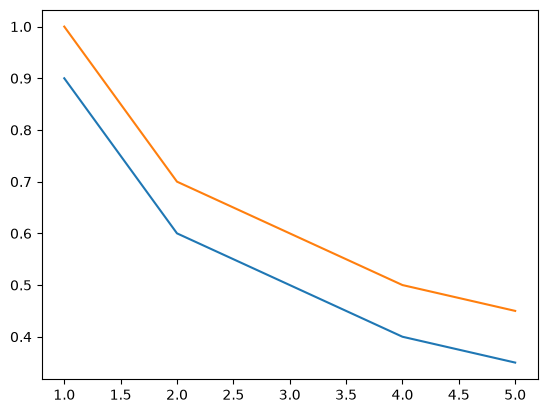

In [2]:
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)

As we can see, they are combined into one figure.
`plt.show()` will make the top `[<matplotlib.lines.Line2D at 0x10f97e120>]` disappear

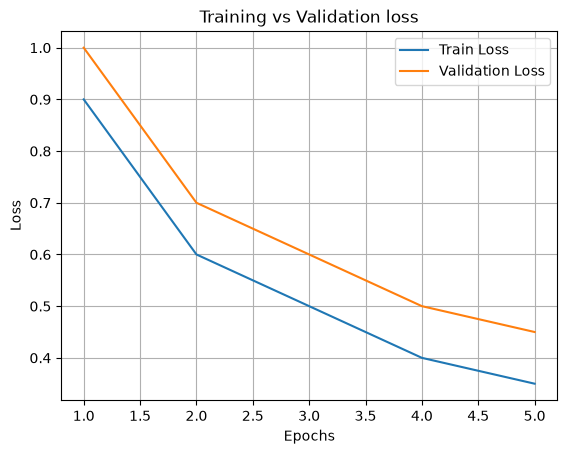

In [3]:
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title('Training vs Validation loss')
plt.legend()
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## 2. Bar Chart - Class Distribution

In [4]:
classes = ['Setosa', 'Versicolor', 'Virginica']
counts = [30, 50, 20]

Text(0, 0.5, 'Count')

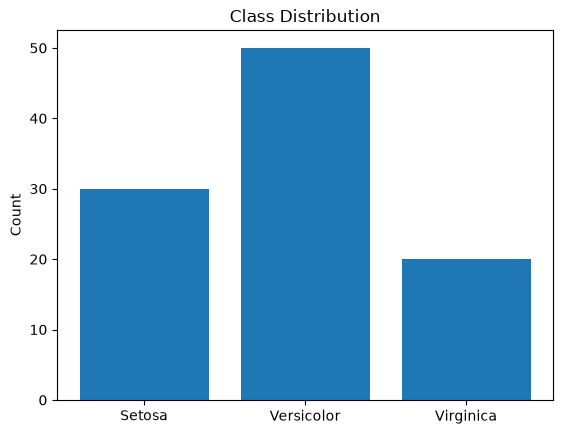

In [5]:
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.ylabel("Count")

## 3. Histrogram - Feature distribution

In [6]:
import seaborn as sns
df = sns.load_dataset("iris")

Text(0.5, 0, 'Length (cm)')

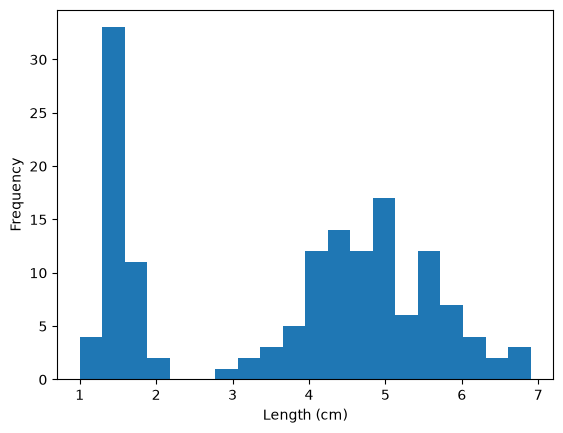

In [7]:
plt.hist(df['petal_length'], bins=20)

plt.ylabel("Frequency")
plt.xlabel("Length (cm)")

## 4. Scatter Plot - Feature Distribution

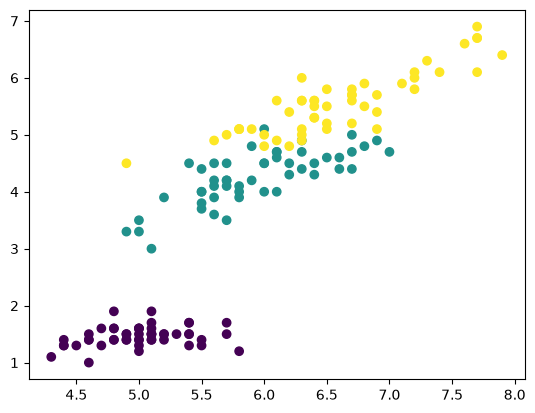

In [8]:
plt.scatter(df['sepal_length'], df['petal_length'], c=df['species'].astype('category').cat.codes)
# x-axis, y-axis, color map based on species and we are creating a category code.


In [9]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# Seaborn - Statistical & ML-friendly plots

## 1. Countplot - Target Class Distribution

In [10]:
df2 = sns.load_dataset('titanic')

Text(0.5, 0, 'Survived (0=No, 1=Yes)')

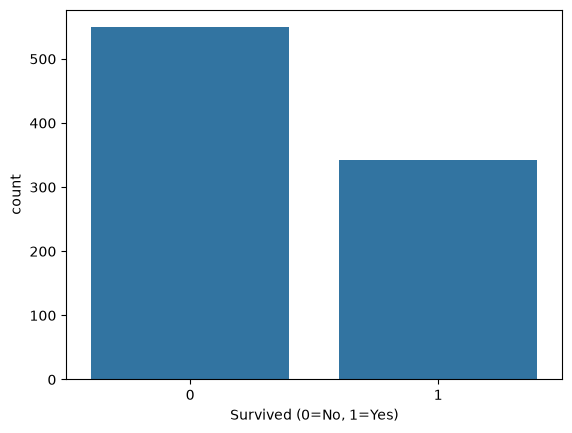

In [11]:
sns.countplot(x='survived', data=df2)
plt.xlabel('Survived (0=No, 1=Yes)')

In [12]:
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Boxplot - Numerical Feature vs Target

<Axes: xlabel='survived', ylabel='age'>

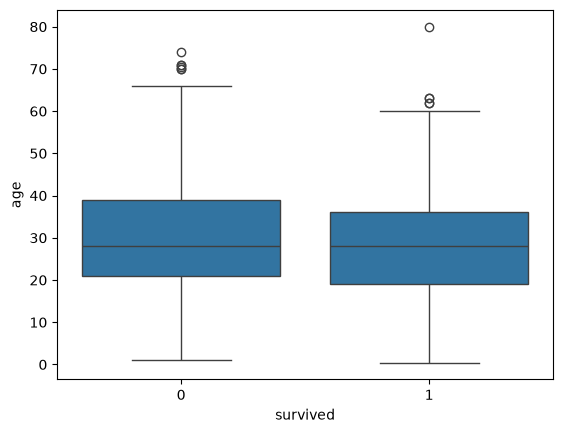

In [13]:
sns.boxplot(x='survived', y='age', data=df2)

## 3. Violin Plot - Class-wise Distribution

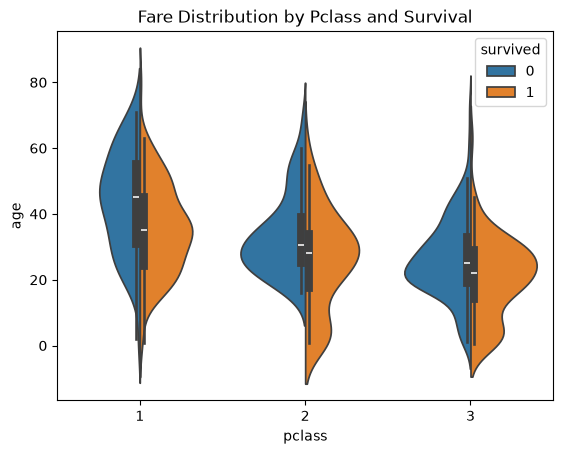

In [14]:
sns.violinplot(x='pclass', y='age', data=df2, hue='survived', split=True)
plt.title('Fare Distribution by Pclass and Survival')
plt.show()

Normally, the **KDE**(Kernel Density Estimation, an estimation of Probability Density Function) curve will extend over the actual data.

To fix this, use `cut=0` attribute.

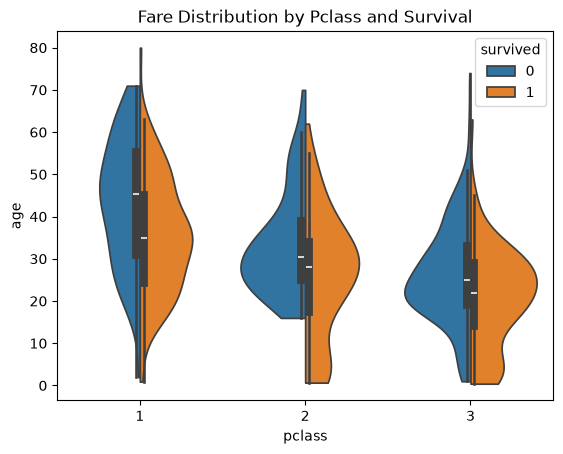

In [15]:
sns.violinplot(x='pclass', y='age', data=df2, hue='survived', split=True, cut=0)
plt.title('Fare Distribution by Pclass and Survival')
plt.show()

## 4. Heatmap - Correlation Matrix

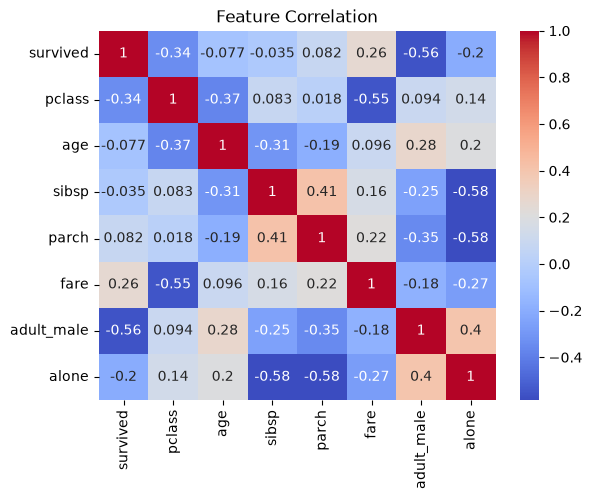

In [16]:
corr = df2.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## 5. Pairplot - Multivariate Analysis

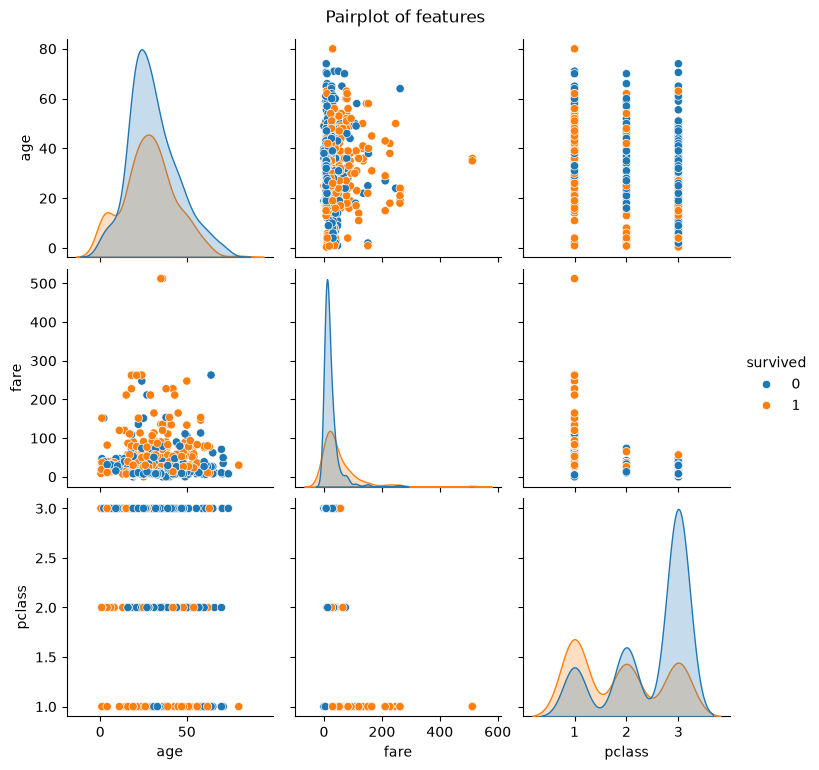

In [17]:
sns.pairplot(df2[['age', 'fare', 'pclass', 'survived']].dropna(), hue='survived')
plt.suptitle("Pairplot of features", y=1.02)
plt.show()

# Plotly

In [18]:
import plotly.express as px

fig = px.scatter(df2, x='age', y='fare', color='survived', size='pclass',
                 hover_data=['sex', 'embarked'], title='Interactive Titanic Plot')
fig.show()

In [19]:
df = px.data.iris()

fig=px.scatter(df, x='sepal_width', y='sepal_length', color='species', size='petal_length')
fig.show()

In [20]:
df = px.data.iris()
fig = px.scatter_3d(
    df,
    x='sepal_width',
    y='sepal_length',
    z='petal_width',
    color='species',
    size='petal_length',
    symbol='species',
    opacity=0.8
)
fig.show()

# Titanic Dataset: Exploratory Data Analysis (EDA)

## Step 1. Load the Dataset

In [21]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load the Titanic Dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 2. Dataset Overview

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


## Step 3. Basic Data Cleaning

In [23]:
# Drop less useful or high missing columns
df.drop(columns=['deck', 'embark_town'], inplace=True)

# Fill missing age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill embarked with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop rows with any remaining missing values
df.dropna(inplace=True)

# Confirm cleanup
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    str     
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    str     
 8   class       891 non-null    category
 9   who         891 non-null    str     
 10  adult_male  891 non-null    bool    
 11  alive       891 non-null    str     
 12  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(4)
memory usage: 82.8 KB


## Step 4: Univariate Analysis

### Survival Count

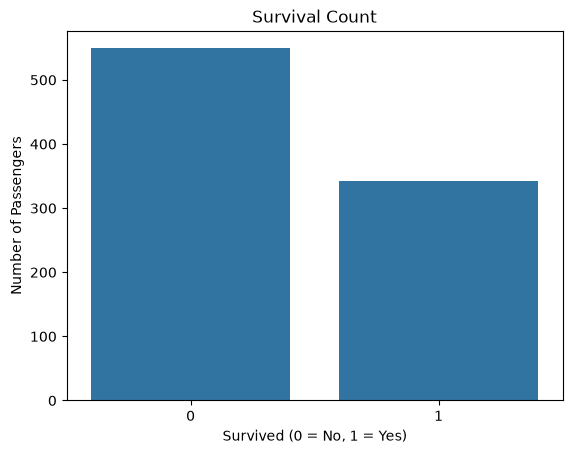

In [25]:
sns.countplot(x='survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

### Age Distribution

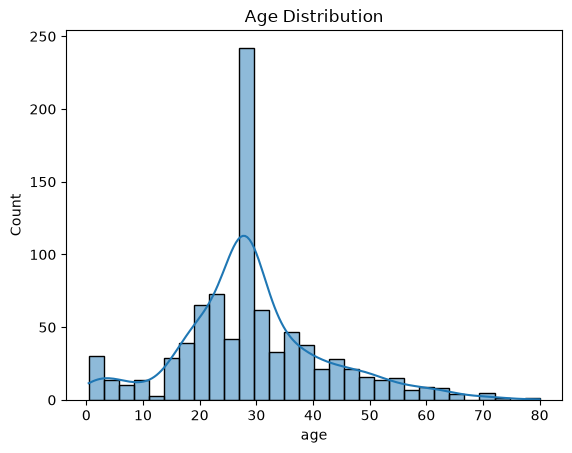

In [27]:
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.show()

### P-class Distribution (Bivariate)

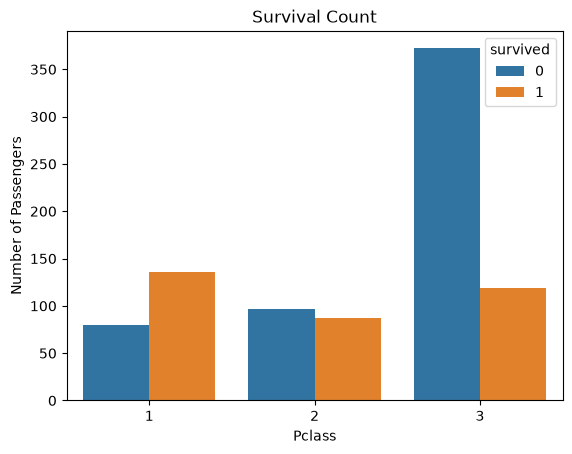

In [30]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival Count')
plt.xlabel('Pclass')
plt.ylabel('Number of Passengers')
plt.show()

## Step 5. Bivariate Analysis

### Gender vs. Survival

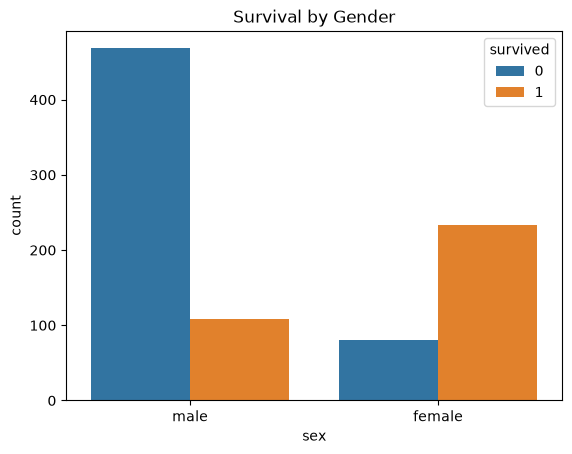

In [29]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Survival by Gender')
plt.show()

## Step 6. Feature Engineering

In [33]:
# Create a new feature: is_child
df['is_child'] = df['age']<18

# Create family size
df['family_size'] = df['sibsp'] + df['parch']

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone,is_child,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True,False,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True,False,0


## Step 7. Saving the new data

In [35]:
df.to_csv("titanic_cleaned.csv", index=False)